In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:

np.random.seed(42)

rows = []

users = [101, 102, 103, 104, 105]
start_time = datetime(2026, 1, 1)

In [3]:
for i in range(300):
    user_id = np.random.choice(users)

    # Normal behavior
    if user_id in [101, 102]:
        amount = np.random.normal(300, 50)
    elif user_id in [103, 104]:
        amount = np.random.normal(5000, 1000)
    else:
        amount = np.random.normal(15000, 3000)

    # Inject anomalies 
    if np.random.rand() < 0.05:
        amount = np.random.uniform(60000, 100000)

    timestamp = start_time + timedelta(
        hours=np.random.randint(0, 24),
        days=np.random.randint(0, 10)
    )

    rows.append([
        user_id,
        round(abs(amount), 2),
        timestamp
    ])


In [4]:
df = pd.DataFrame(rows, columns=["user_id", "amount", "timestamp"])
df.sort_values("timestamp", inplace=True)

df.head()


,user_id,amount,timestamp
25,104,5314.51,2026-01-01 00:00:00
119,103,6355.97,2026-01-01 03:00:00
86,102,324.61,2026-01-01 04:00:00
248,102,327.55,2026-01-01 04:00:00
219,102,271.88,2026-01-01 04:00:00


In [5]:
df.describe()

,user_id,amount,timestamp
count,300.000000,300.000000,300
mean,103.040000,7941.040300,2026-01-05 21:54:00
min,101.000000,126.090000,2026-01-01 00:00:00
25%,102.000000,320.410000,2026-01-03 06:45:00
50%,103.000000,4471.845000,2026-01-05 16:30:00
75%,104.250000,10490.147500,2026-01-08 14:15:00
max,105.000000,97448.490000,2026-01-10 23:00:00
std,1.491918,14392.228833,NaN


<Axes: >

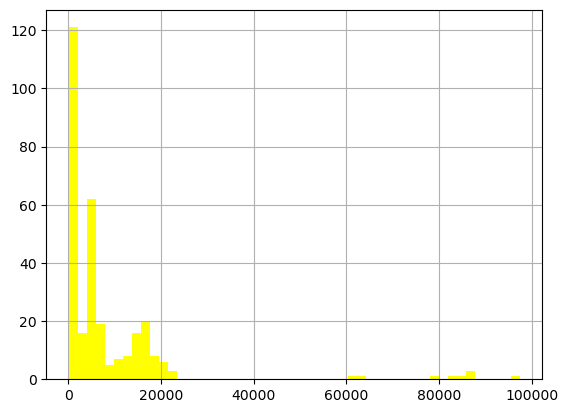

In [6]:
df['amount'].hist(bins=50,color='yellow')


In [7]:
df.to_csv("data/processed_transactions.csv", index=False)
print("CSV file created successfully!")

CSV file created successfully!


In [8]:
df.columns

Index(['user_id', 'amount', 'timestamp'], dtype='object')